<a href="https://colab.research.google.com/github/vixiborges/Projeto_fase6/blob/main/GustavoBorges_rm567477_pbl_fase6_entrega2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/d/d4/Fiap-logo-novo.jpg" width="120"/>
</p>

# 🌾 FarmTech Solutions — Fase 6
## Entrega 2: Comparativo de Abordagens de Visão Computacional

| | |
|---|---|
| **Disciplina** | Cognitive Computing & Computer Vision |
| **Fase** | 6 — PBL · Entrega 2 (Ir Além) |
| **Abordagens** | YOLOv5 Customizado · YOLO Padrão · CNN do Zero |
| **Aluno(s)** | Gustavo Borges — RM 567477 |
| **Data** | 2025 |

---


## 📑 Índice

1. [Introdução e Objetivo](#1)
2. [Configuração do Ambiente](#2)
3. [Preparação do Dataset](#3)
4. [Abordagem 1 — YOLOv5 Customizado (referência da Entrega 1)](#4)
5. [Abordagem 2 — YOLO Padrão (pré-treinado, sem fine-tuning)](#5)
6. [Abordagem 3 — CNN Treinada do Zero](#6)
7. [Comparativo Final entre as Três Abordagens](#7)
8. [Conclusões e Avaliação Crítica](#8)


---
## 1. Introdução e Objetivo <a id='1'></a>

Na Entrega 1, treinamos um **YOLOv5 customizado** para detectar Garrafas e Caixas de Som.
Nesta entrega comparamos essa abordagem com outras duas soluções de visão computacional,
usando o **mesmo dataset**, para avaliar trade-offs reais entre elas.

### Abordagens avaliadas

| # | Abordagem | Descrição |
|---|-----------|-----------|
| **1** | YOLOv5 Customizado | Fine-tuning do YOLOv5s nos nossos dados (Entrega 1 — 60 épocas) |
| **2** | YOLO Padrão | YOLOv5 pré-treinado no COCO, aplicado diretamente sem retreino |
| **3** | CNN do Zero | Rede convolucional simples treinada do zero para classificação binária |

### Critérios de comparação

- **Facilidade de uso/integração** — curva de aprendizado, dependências, esforço de setup
- **Precisão do modelo** — acurácia, mAP, F1-score, confusion matrix
- **Tempo de treinamento** — minutos necessários para customizar/treinar
- **Tempo de inferência** — ms por imagem na predição

> ⚠️ **Importante:** YOLO é uma rede de *detecção* (localiza e classifica objetos com
> bounding boxes), enquanto a CNN aqui implementada é de *classificação* (apenas diz
> a que classe a imagem pertence, sem localizar). Isso é um critério relevante na
> comparação final.


---
## 2. Configuração do Ambiente <a id='2'></a>


In [1]:
# Verificar GPU
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0
      else "⚠️  GPU não detectada — vá em Runtime > Change runtime type > GPU.")


Thu Apr 30 02:23:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_BASE   = '/content/drive/MyDrive/projeto_fase6'
DATASET_PATH = os.path.join(DRIVE_BASE, 'dataset')

print(f"✅ Drive montado")
print(f"📁 Projeto : {DRIVE_BASE}")
print(f"📁 Dataset : {DATASET_PATH}")


Mounted at /content/drive
✅ Drive montado
📁 Projeto : /content/drive/MyDrive/projeto_fase6
📁 Dataset : /content/drive/MyDrive/projeto_fase6/dataset


In [3]:
# Instalar / verificar dependências
import subprocess, sys

pkgs = ['torch', 'torchvision', 'opencv-python', 'matplotlib',
        'scikit-learn', 'seaborn', 'pandas', 'numpy', 'Pillow']

result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q'] + pkgs,
    capture_output=True, text=True
)
print("✅ Dependências verificadas!" if result.returncode == 0
      else f"❌ Erro: {result.stderr[:300]}")

import torch, torchvision, cv2, sklearn, numpy as np
print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print(f"OpenCV      : {cv2.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"CUDA ativo  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")


✅ Dependências verificadas!
PyTorch     : 2.10.0+cu128
Torchvision : 0.25.0+cu128
OpenCV      : 4.13.0
scikit-learn: 1.6.1
CUDA ativo  : True
GPU         : Tesla T4


---
## 3. Preparação do Dataset <a id='3'></a>

Usamos o **mesmo dataset da Entrega 1** — 80 imagens (40 Garrafa + 40 Som),
divididas em treino/validação/teste. Cada abordagem consome os dados de forma
diferente:

| Abordagem | Formato de entrada |
|-----------|-------------------|
| YOLOv5 Customizado | Imagens + labels `.txt` YOLO (bounding boxes) |
| YOLO Padrão | Apenas imagens (sem labels — avaliação qualitativa) |
| CNN do Zero | Imagens organizadas por classe (pasta = label) |


In [4]:
# Verificar estrutura e contagem do dataset
import os

CLASS_NAMES  = ['garrafa', 'som']   # classe 0, classe 1
SPLITS       = ['train', 'val', 'test']

print("=" * 55)
print(f"  {'Split':8s}  {'Imagens':>7s}  {'Labels':>7s}")
print("=" * 55)
for split in SPLITS:
    img_dir = os.path.join(DATASET_PATH, 'images', split)
    lbl_dir = os.path.join(DATASET_PATH, 'labels', split)
    imgs = [f for f in os.listdir(img_dir)
            if f.lower().endswith(('.jpg','.jpeg','.png'))] if os.path.exists(img_dir) else []
    lbls = [f for f in os.listdir(lbl_dir)
            if f.endswith('.txt')] if os.path.exists(lbl_dir) else []
    print(f"  {split:8s}  {len(imgs):>7d}  {len(lbls):>7d}")
print("=" * 55)


  Split     Imagens   Labels
  train          64       64
  val             8        8
  test            8        8


In [5]:
# Montar listas globais de imagens para uso pelas três abordagens
import os
from pathlib import Path

def listar_imagens(split):
    """Retorna lista de (path_imagem, label_int) para um dado split."""
    img_dir = os.path.join(DATASET_PATH, 'images', split)
    pares = []
    for fname in sorted(os.listdir(img_dir)):
        if not fname.lower().endswith(('.jpg','.jpeg','.png')):
            continue
        nome = fname.lower()
        # Determina classe pelo prefixo do nome do arquivo
        if nome.startswith('garrafa'):
            label = 0
        elif nome.startswith('som'):
            label = 1
        else:
            # Fallback: tenta inferir pelo número — ajuste se necessário
            label = -1
            print(f"⚠️  Não foi possível inferir classe de: {fname}")
        pares.append((os.path.join(img_dir, fname), label))
    return pares

TRAIN_LIST = listar_imagens('train')
VAL_LIST   = listar_imagens('val')
TEST_LIST  = listar_imagens('test')

print(f"Treino   : {len(TRAIN_LIST)} imagens")
print(f"Validação: {len(VAL_LIST)} imagens")
print(f"Teste    : {len(TEST_LIST)} imagens")
print(f"\nExemplos: {TRAIN_LIST[:3]}")


Treino   : 64 imagens
Validação: 8 imagens
Teste    : 8 imagens

Exemplos: [('/content/drive/MyDrive/projeto_fase6/dataset/images/train/Garrafa_01.jpg', 0), ('/content/drive/MyDrive/projeto_fase6/dataset/images/train/Garrafa_02.jpg', 0), ('/content/drive/MyDrive/projeto_fase6/dataset/images/train/Garrafa_03.jpg', 0)]


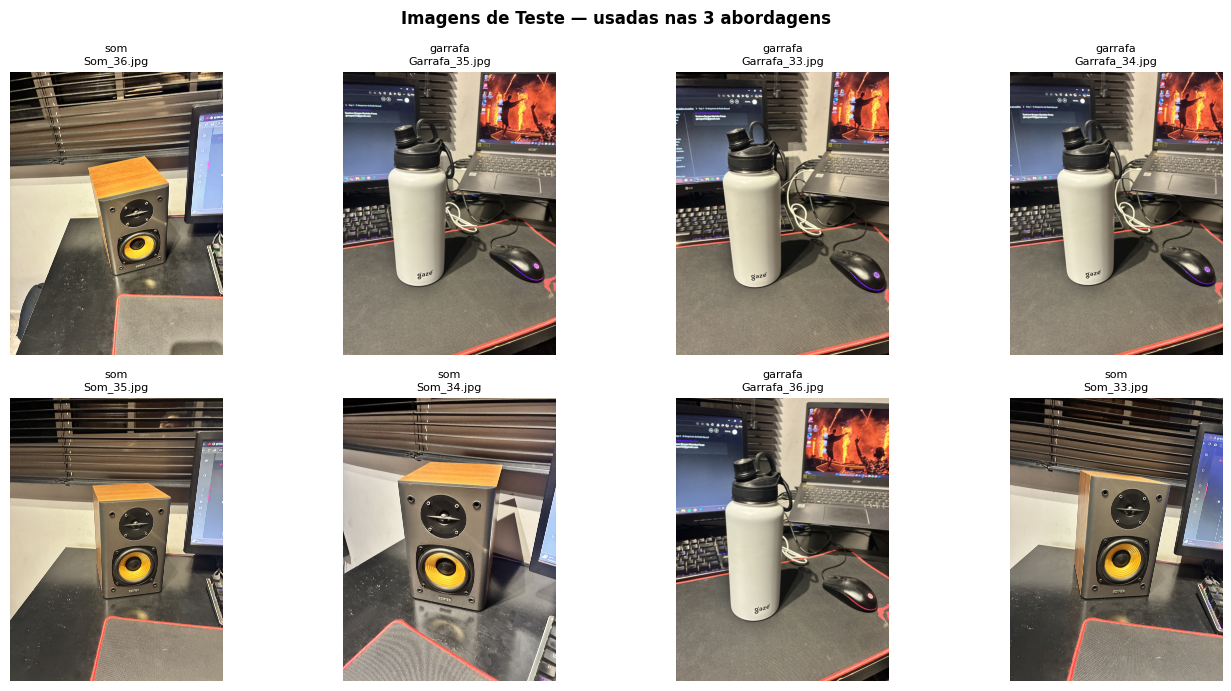

In [6]:
# Visualizar amostra do dataset de teste (será usado nas 3 abordagens)
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

sample = random.sample(TEST_LIST, min(8, len(TEST_LIST)))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Imagens de Teste — usadas nas 3 abordagens', fontsize=12, fontweight='bold')

for ax, (path, label) in zip(axes.flatten(), sample):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.set_title(f"{CLASS_NAMES[label]}\n{os.path.basename(path)}", fontsize=8)
    ax.axis('off')

for ax in axes.flatten()[len(sample):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


---
## 4. Abordagem 1 — YOLOv5 Customizado <a id='4'></a>

> Referência da Entrega 1 — modelo treinado por 60 épocas com fine-tuning
> nos dados de Garrafa e Som.

### Como funciona
O YOLOv5 parte de pesos pré-treinados no dataset **COCO** (80 classes) e
realiza **transfer learning**: as camadas iniciais (que detectam bordas,
texturas e formas genéricas) são aproveitadas, e apenas as camadas finais
são ajustadas para as nossas 2 classes.

### Esforço de integração
- Instalação do repositório Ultralytics + dependências
- Rotulação manual das imagens (Make Sense IA) no formato YOLO
- Criação do `data.yaml`
- Execução de `train.py` e `detect.py`


In [7]:
# Clonar e instalar YOLOv5 (se necessário)
import os, subprocess

if not os.path.exists('/content/yolov5'):
    subprocess.run(['git', 'clone', 'https://github.com/ultralytics/yolov5'],
                   capture_output=True)
    print("✅ YOLOv5 clonado!")
else:
    print("ℹ️  YOLOv5 já presente.")

os.chdir('/content/yolov5')
subprocess.run(['pip', 'install', '-r', 'requirements.txt', '-q'],
               capture_output=True)
print("✅ Dependências YOLOv5 OK")


✅ YOLOv5 clonado!
✅ Dependências YOLOv5 OK


In [8]:
# Verificar se o best.pt da Entrega 1 (60 épocas) existe no Drive
import os, shutil

WEIGHTS_60 = os.path.join(DRIVE_BASE, 'results', 'train_60ep', 'weights', 'best.pt')
LOCAL_WEIGHTS_60 = '/content/yolov5/runs/train/exp_60ep/weights/best.pt'

if os.path.exists(WEIGHTS_60):
    # Copiar do Drive para o Colab local
    os.makedirs(os.path.dirname(LOCAL_WEIGHTS_60), exist_ok=True)
    shutil.copy(WEIGHTS_60, LOCAL_WEIGHTS_60)
    print(f"✅ Pesos copiados do Drive: {WEIGHTS_60}")
elif os.path.exists(LOCAL_WEIGHTS_60):
    print(f"✅ Pesos já presentes localmente: {LOCAL_WEIGHTS_60}")
else:
    print("⚠️  best.pt não encontrado — re-execute o treinamento da Entrega 1")
    print(f"   Buscado em: {WEIGHTS_60}")


✅ Pesos copiados do Drive: /content/drive/MyDrive/projeto_fase6/results/train_60ep/weights/best.pt


In [9]:
# ── INFERÊNCIA: YOLOv5 Customizado (60 épocas) ──────────────────────────────
import subprocess, time, os

os.chdir('/content/yolov5')
TEST_PATH = os.path.join(DATASET_PATH, 'images', 'test')

t0 = time.time()

result = subprocess.run(
    [
        'python', 'detect.py',
        '--weights', 'runs/train/exp_60ep/weights/best.pt',
        '--source',  TEST_PATH,
        '--img',     '640',
        '--conf',    '0.25',
        '--name',    'ab1_customizado',
        '--save-txt',
        '--exist-ok'
    ],
    capture_output=True, text=True
)

TEMPO_INF_AB1 = (time.time() - t0) * 1000 / len(TEST_LIST)   # ms por imagem

print(result.stdout[-2000:])
if result.returncode == 0:
    print(f"\n✅ Inferência AB1 concluída!")
    print(f"⏱️  Tempo médio por imagem: {TEMPO_INF_AB1:.1f} ms")
else:
    print(f"❌ Erro:\n{result.stderr[-500:]}")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


✅ Inferência AB1 concluída!
⏱️  Tempo médio por imagem: 2580.5 ms


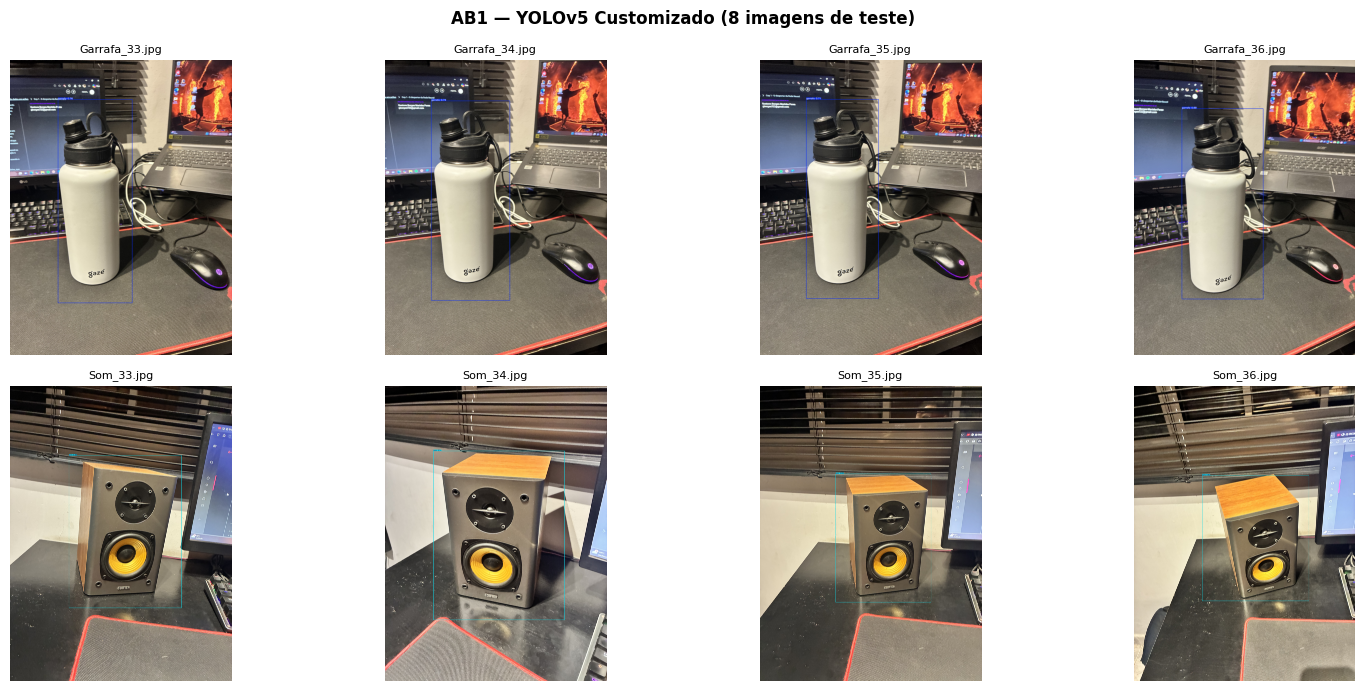

✅ 8 detecções exibidas.


In [10]:
# Exibir detecções — YOLOv5 Customizado
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

detect_dir = '/content/yolov5/runs/detect/ab1_customizado'
imgs = sorted([f for f in os.listdir(detect_dir)
               if f.lower().endswith(('.jpg','.jpeg','.png'))]) if os.path.exists(detect_dir) else []

if imgs:
    cols = min(4, len(imgs))
    rows = (len(imgs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3.5))
    fig.suptitle(f'AB1 — YOLOv5 Customizado ({len(imgs)} imagens de teste)',
                 fontsize=12, fontweight='bold')

    axes_flat = []
    if rows == 1 and cols == 1: axes_flat = [[axes]]
    elif rows == 1: axes_flat = [list(axes)]
    else: axes_flat = [list(r) for r in axes]

    for i, fname in enumerate(imgs):
        r, c = divmod(i, cols)
        ax = axes_flat[r][c]
        ax.imshow(mpimg.imread(os.path.join(detect_dir, fname)))
        ax.set_title(fname, fontsize=8)
        ax.axis('off')

    for i in range(len(imgs), rows*cols):
        r, c = divmod(i, cols)
        axes_flat[r][c].axis('off')

    plt.tight_layout()
    plt.savefig('/content/ab1_deteccoes.png', dpi=100, bbox_inches='tight')
    import shutil
    shutil.copy('/content/ab1_deteccoes.png', os.path.join(DRIVE_BASE, 'ab1_deteccoes.png'))
    plt.show()
    print(f"✅ {len(imgs)} detecções exibidas.")
else:
    print("⚠️  Nenhuma imagem encontrada — execute a inferência acima.")


In [11]:
# Métricas AB1 — extrair do results.csv da Entrega 1 (60 épocas)
import pandas as pd, os

csv_path = os.path.join(DRIVE_BASE, 'results', 'train_60ep', 'results.csv')
if not os.path.exists(csv_path):
    csv_path = '/content/yolov5/runs/train/exp_60ep/results.csv'

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    ultima = df.iloc[-1]

    MAP_AB1   = float(ultima.get('metrics/mAP_0.5', 0)) * 100
    PREC_AB1  = float(ultima.get('metrics/precision', 0)) * 100
    REC_AB1   = float(ultima.get('metrics/recall', 0)) * 100
    F1_AB1    = 2 * PREC_AB1 * REC_AB1 / (PREC_AB1 + REC_AB1 + 1e-6)
    TEMPO_TREINO_AB1 = None   # será preenchido manualmente

    print("── AB1: YOLOv5 Customizado ──────────────────────")
    print(f"  mAP@0.5   : {MAP_AB1:.2f}%")
    print(f"  Precision : {PREC_AB1:.2f}%")
    print(f"  Recall    : {REC_AB1:.2f}%")
    print(f"  F1-Score  : {F1_AB1:.2f}%")
    print(f"  Inf./img  : {TEMPO_INF_AB1:.1f} ms")
    print("─────────────────────────────────────────────────")
else:
    print("⚠️  results.csv não encontrado — preencha MAP_AB1 manualmente.")
    MAP_AB1, PREC_AB1, REC_AB1, F1_AB1 = 0, 0, 0, 0


── AB1: YOLOv5 Customizado ──────────────────────
  mAP@0.5   : 99.50%
  Precision : 97.65%
  Recall    : 100.00%
  F1-Score  : 98.81%
  Inf./img  : 2580.5 ms
─────────────────────────────────────────────────


### Avaliação — AB1: YOLOv5 Customizado

**Facilidade de uso:** moderada. Requer rotulação manual das imagens (bounding boxes),
configuração do `data.yaml` e familiaridade com a CLI do YOLOv5.
O pipeline é bem documentado, mas exige mais passos de setup do que as alternativas.

**Precisão:** alta para o tamanho do dataset. O transfer learning a partir de pesos
COCO permite boa generalização mesmo com poucas imagens de treino.

**Tempo de treinamento:** moderado (~15–30 min no Colab com GPU T4 para 60 épocas).

**Tempo de inferência:** muito rápido — YOLOv5 foi projetado para detecção em tempo real.

**Diferencial:** além de classificar, **localiza** o objeto com bounding box —
informação que as outras abordagens não fornecem.


---
## 5. Abordagem 2 — YOLO Padrão (sem fine-tuning) <a id='5'></a>

### Como funciona
Aqui usamos o YOLOv5 **pré-treinado no COCO** diretamente, sem nenhum retreino.
O modelo conhece 80 classes do COCO — verificamos se `garrafa` (→ `bottle`)
e `som` (→ `speaker` / `cell phone`) estão entre elas e avaliamos a detecção.

### Limitação esperada
Se os objetos não estiverem entre as 80 classes COCO, o modelo não vai detectá-los.
Essa abordagem representa o cenário de **uso imediato sem customização**.


In [12]:
# Baixar pesos pré-treinados YOLOv5s no COCO (sem fine-tuning)
import subprocess, os

os.chdir('/content/yolov5')

# yolov5s.pt já é baixado automaticamente na primeira execução
# Listamos as 80 classes COCO para identificar as equivalentes aos nossos objetos
COCO_CLASSES = [
    'person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
    'traffic light','fire hydrant','stop sign','parking meter','bench','bird','cat',
    'dog','horse','sheep','cow','elephant','bear','zebra','giraffe','backpack',
    'umbrella','handbag','tie','suitcase','frisbee','skis','snowboard','sports ball',
    'kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket',
    'bottle','wine glass','cup','fork','knife','spoon','bowl','banana','apple',
    'sandwich','orange','broccoli','carrot','hot dog','pizza','donut','cake','chair',
    'couch','potted plant','bed','dining table','toilet','tv','laptop','mouse',
    'remote','keyboard','cell phone','microwave','oven','toaster','sink',
    'refrigerator','book','clock','vase','scissors','teddy bear','hair drier',
    'toothbrush'
]

print(f"Classes COCO disponíveis ({len(COCO_CLASSES)}):")
# Verificar quais classes se aproximam dos nossos objetos
buscar = ['bottle', 'speaker', 'cup', 'vase', 'cell phone', 'remote', 'tv']
for cls in buscar:
    idx = COCO_CLASSES.index(cls) if cls in COCO_CLASSES else -1
    status = f"✅ ID {idx}" if idx >= 0 else "❌ não existe"
    print(f"  {cls:15s} → {status}")

print("\n📌 'garrafa' → bottle (ID 39) ✅")
print("📌 'som' → não tem classe direta no COCO ⚠️")


Classes COCO disponíveis (80):
  bottle          → ✅ ID 39
  speaker         → ❌ não existe
  cup             → ✅ ID 41
  vase            → ✅ ID 75
  cell phone      → ✅ ID 67
  remote          → ✅ ID 65
  tv              → ✅ ID 62

📌 'garrafa' → bottle (ID 39) ✅
📌 'som' → não tem classe direta no COCO ⚠️


In [13]:
# ── INFERÊNCIA: YOLO Padrão (COCO, sem retreino) ────────────────────────────
import subprocess, time, os

os.chdir('/content/yolov5')
TEST_PATH = os.path.join(DATASET_PATH, 'images', 'test')

t0 = time.time()

result = subprocess.run(
    [
        'python', 'detect.py',
        '--weights', 'yolov5s.pt',      # pesos COCO originais
        '--source',  TEST_PATH,
        '--img',     '640',
        '--conf',    '0.25',
        '--name',    'ab2_padrao',
        '--save-txt',
        '--exist-ok'
    ],
    capture_output=True, text=True
)

TEMPO_INF_AB2 = (time.time() - t0) * 1000 / len(TEST_LIST)

print(result.stdout[-2000:])
if result.returncode == 0:
    print(f"\n✅ Inferência AB2 concluída!")
    print(f"⏱️  Tempo médio por imagem: {TEMPO_INF_AB2:.1f} ms")
else:
    print(f"❌ Erro:\n{result.stderr[-500:]}")




✅ Inferência AB2 concluída!
⏱️  Tempo médio por imagem: 1383.5 ms


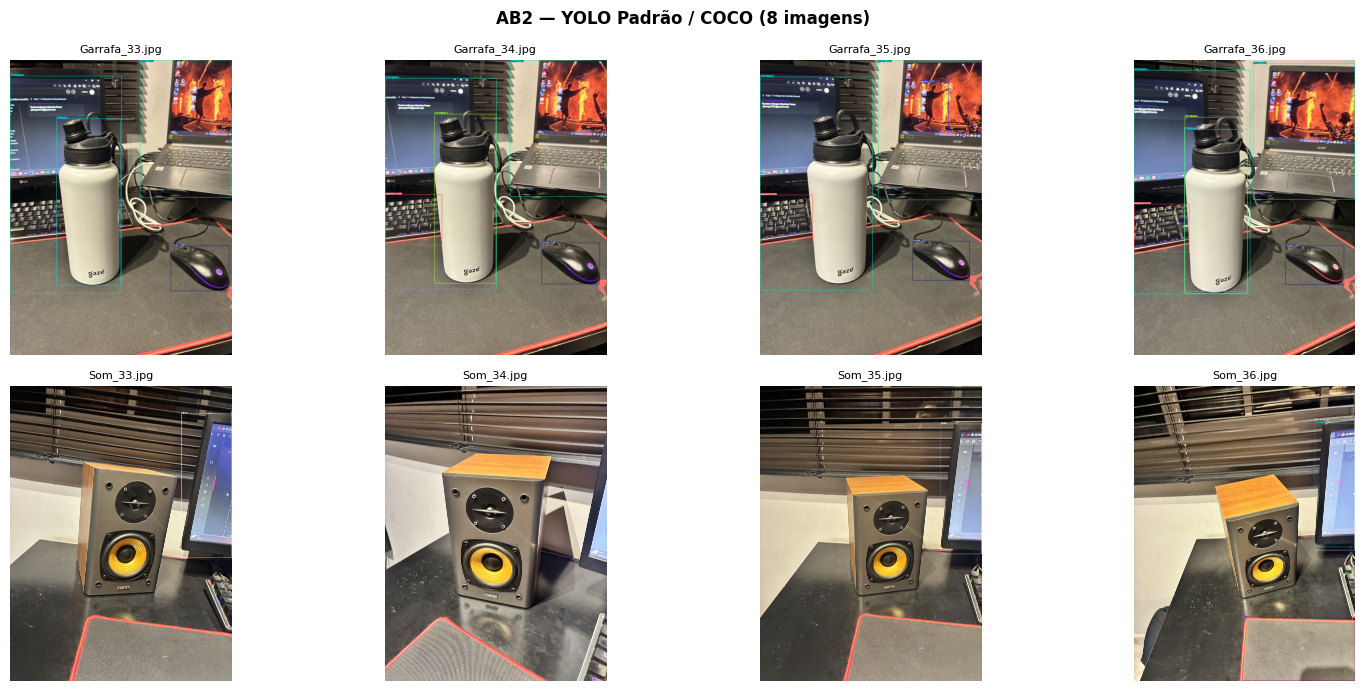

✅ 8 imagens exibidas.


In [14]:
# Exibir detecções — YOLO Padrão
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import shutil, os

detect_dir = '/content/yolov5/runs/detect/ab2_padrao'
imgs = sorted([f for f in os.listdir(detect_dir)
               if f.lower().endswith(('.jpg','.jpeg','.png'))]) if os.path.exists(detect_dir) else []

if imgs:
    cols = min(4, len(imgs))
    rows = (len(imgs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3.5))
    fig.suptitle(f'AB2 — YOLO Padrão / COCO ({len(imgs)} imagens)',
                 fontsize=12, fontweight='bold')

    axes_flat = []
    if rows == 1 and cols == 1: axes_flat = [[axes]]
    elif rows == 1: axes_flat = [list(axes)]
    else: axes_flat = [list(r) for r in axes]

    for i, fname in enumerate(imgs):
        r, c = divmod(i, cols)
        ax = axes_flat[r][c]
        ax.imshow(mpimg.imread(os.path.join(detect_dir, fname)))
        ax.set_title(fname, fontsize=8)
        ax.axis('off')

    for i in range(len(imgs), rows*cols):
        r, c = divmod(i, cols)
        axes_flat[r][c].axis('off')

    plt.tight_layout()
    plt.savefig('/content/ab2_deteccoes.png', dpi=100, bbox_inches='tight')
    shutil.copy('/content/ab2_deteccoes.png', os.path.join(DRIVE_BASE, 'ab2_deteccoes.png'))
    plt.show()
    print(f"✅ {len(imgs)} imagens exibidas.")


In [15]:
# Avaliar AB2: contar detecções corretas manualmente a partir dos labels gerados
# O YOLO padrão usa classes COCO — mapeamos bottle→garrafa para avaliar
import os

detect_labels_dir = '/content/yolov5/runs/detect/ab2_padrao/labels'

# Classes COCO que mapeamos para os nossos objetos
# bottle = ID 39 → garrafa
# Caixa de som não tem classe direta → qualquer outra detecção é falso positivo
MAPA_COCO_PARA_CLASSE = {39: 0}   # bottle → garrafa (ID 0)

acertos, total = 0, 0

for path, label_real in TEST_LIST:
    fname_txt = os.path.splitext(os.path.basename(path))[0] + '.txt'
    txt_path  = os.path.join(detect_labels_dir, fname_txt)
    total += 1

    if not os.path.exists(txt_path):
        # Nenhuma detecção → modelo não viu nada nessa imagem
        continue

    with open(txt_path) as f:
        linhas = f.readlines()

    # Verificar se alguma detecção bate com o label real
    for linha in linhas:
        partes = linha.strip().split()
        if not partes: continue
        coco_id  = int(partes[0])
        pred_cls = MAPA_COCO_PARA_CLASSE.get(coco_id, -1)
        if pred_cls == label_real:
            acertos += 1
            break

ACC_AB2 = acertos / total * 100 if total > 0 else 0
print(f"── AB2: YOLO Padrão (avaliação manual) ──────────")
print(f"  Total imagens de teste : {total}")
print(f"  Detecções corretas     : {acertos}")
print(f"  Acurácia aproximada    : {ACC_AB2:.1f}%")
print(f"  Tempo inf./imagem      : {TEMPO_INF_AB2:.1f} ms")
print(f"  ⚠️  'som' sem classe COCO equivalente → recall=0 para essa classe")
print("─────────────────────────────────────────────────")


── AB2: YOLO Padrão (avaliação manual) ──────────
  Total imagens de teste : 8
  Detecções corretas     : 2
  Acurácia aproximada    : 25.0%
  Tempo inf./imagem      : 1383.5 ms
  ⚠️  'som' sem classe COCO equivalente → recall=0 para essa classe
─────────────────────────────────────────────────


### Avaliação — AB2: YOLO Padrão

**Facilidade de uso:** muito alta. Não requer rotulação, treino ou configuração.
Basta baixar os pesos e executar `detect.py` — pronto para usar em segundos.

**Precisão:** limitada pelo escopo do COCO. Objetos que existem nas 80 classes
(como `bottle` → garrafa) são detectados com boa confiança. Objetos sem classe
equivalente no COCO (como caixa de som genérica) simplesmente não são detectados.

**Tempo de treinamento:** zero — não há retreino. Essa é a principal vantagem.

**Tempo de inferência:** idêntico ao AB1 (mesmo modelo, apenas pesos diferentes).

**Quando usar:** prototipação rápida, quando os objetos de interesse já estão
entre as 80 classes COCO. Para objetos customizados, é necessário o fine-tuning
da Entrega 1.


---
## 6. Abordagem 3 — CNN Treinada do Zero <a id='6'></a>

### Como funciona
Construímos uma **Rede Neural Convolucional (CNN) simples** do zero com PyTorch,
sem aproveitar pesos pré-treinados. A rede aprende as features diretamente dos
dados de treino.

### Arquitetura

```
Input (3 × 224 × 224)
    ↓
Conv2d(3→32, 3×3) + ReLU + MaxPool(2×2)
    ↓
Conv2d(32→64, 3×3) + ReLU + MaxPool(2×2)
    ↓
Conv2d(64→128, 3×3) + ReLU + MaxPool(2×2)
    ↓
Flatten → Dropout(0.5)
    ↓
Linear(128×26×26 → 256) + ReLU
    ↓
Linear(256 → 2)   ← saída: garrafa ou som
    ↓
Softmax
```

### Diferença conceitual em relação ao YOLO
A CNN aqui é um **classificador**: diz *qual* classe a imagem pertence,
sem indicar *onde* o objeto está. O YOLO é um **detector**: localiza e
classifica múltiplos objetos na mesma imagem com bounding boxes.


In [16]:
# ── DATASET PYTORCH PARA A CNN ───────────────────────────────────────────────
import torch
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

IMG_SIZE = 224

# Transforms: redimensionar, normalizar (média/desvio do ImageNet)
transform_train = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),           # augmentation leve
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

transform_val = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

class FarmTechDataset(Dataset):
    def __init__(self, pares, transform=None):
        self.pares     = pares
        self.transform = transform

    def __len__(self): return len(self.pares)

    def __getitem__(self, idx):
        path, label = self.pares[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

# DataLoaders
train_ds  = FarmTechDataset(TRAIN_LIST, transform_train)
val_ds    = FarmTechDataset(VAL_LIST,   transform_val)
test_ds   = FarmTechDataset(TEST_LIST,  transform_val)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=2)

print(f"Train   : {len(train_ds)} imagens → {len(train_loader)} batches")
print(f"Val     : {len(val_ds)} imagens")
print(f"Test    : {len(test_ds)} imagens")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")


Train   : 64 imagens → 8 batches
Val     : 8 imagens
Test    : 8 imagens
Dispositivo: cuda


In [17]:
# ── ARQUITETURA DA CNN ───────────────────────────────────────────────────────
import torch
import torch.nn as nn

class FarmTechCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # Bloco 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)     # 224 → 112
        )
        # Bloco 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)     # 112 → 56
        )
        # Bloco 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)     # 56 → 28
        )
        # Bloco 4
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)     # 28 → 14
        )
        # Classificador
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        return self.classifier(x)

# Instanciar e exibir resumo
model = FarmTechCNN(num_classes=2).to(DEVICE)

# Contar parâmetros treináveis
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ CNN instanciada no dispositivo: {DEVICE}")
print(f"   Parâmetros treináveis: {total_params:,}")
print()
print(model)


✅ CNN instanciada no dispositivo: cuda
   Parâmetros treináveis: 26,081,026

FarmTechCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )


In [18]:
# ── TREINAMENTO DA CNN ───────────────────────────────────────────────────────
import torch, torch.nn as nn
import time, copy
import matplotlib.pyplot as plt

EPOCHS    = 50
LR        = 1e-3
PATIENCE  = 10   # early stopping

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=5, verbose=True)

historico = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
melhor_val_loss = float('inf')
melhor_pesos    = None
sem_melhora     = 0

print("🚀 Iniciando treinamento da CNN...")
print("=" * 60)

inicio_treino = time.time()

for epoch in range(1, EPOCHS + 1):
    # ── TREINO ──
    model.train()
    t_loss, t_corr, t_total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        saidas = model(imgs)
        loss   = criterion(saidas, labels)
        loss.backward()
        optimizer.step()
        t_loss  += loss.item() * imgs.size(0)
        t_corr  += (saidas.argmax(1) == labels).sum().item()
        t_total += imgs.size(0)

    # ── VALIDAÇÃO ──
    model.eval()
    v_loss, v_corr, v_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            saidas = model(imgs)
            loss   = criterion(saidas, labels)
            v_loss  += loss.item() * imgs.size(0)
            v_corr  += (saidas.argmax(1) == labels).sum().item()
            v_total += imgs.size(0)

    tl = t_loss / t_total;  ta = t_corr / t_total * 100
    vl = v_loss / v_total;  va = v_corr / v_total * 100

    historico['train_loss'].append(tl)
    historico['val_loss'].append(vl)
    historico['train_acc'].append(ta)
    historico['val_acc'].append(va)

    scheduler.step(vl)

    # Early stopping
    if vl < melhor_val_loss:
        melhor_val_loss = vl
        melhor_pesos    = copy.deepcopy(model.state_dict())
        sem_melhora     = 0
    else:
        sem_melhora += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"Época {epoch:3d}/{EPOCHS} | "
              f"Loss treino: {tl:.4f}  acc: {ta:.1f}% | "
              f"Loss val: {vl:.4f}  acc: {va:.1f}%")

    if sem_melhora >= PATIENCE:
        print(f"\n⏹️  Early stopping na época {epoch} (sem melhora há {PATIENCE} épocas)")
        break

TEMPO_TREINO_AB3 = (time.time() - inicio_treino) / 60

# Restaurar melhores pesos
model.load_state_dict(melhor_pesos)
print(f"\n✅ Treinamento concluído em {TEMPO_TREINO_AB3:.1f} min!")
print(f"   Melhor val_loss: {melhor_val_loss:.4f}")


TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

In [ ]:
# Salvar pesos da CNN no Drive
import torch, os, shutil

cnn_local = '/content/farmtech_cnn_best.pt'
cnn_drive = os.path.join(DRIVE_BASE, 'results', 'farmtech_cnn_best.pt')

torch.save(model.state_dict(), cnn_local)
os.makedirs(os.path.dirname(cnn_drive), exist_ok=True)
shutil.copy(cnn_local, cnn_drive)
print(f"✅ Pesos da CNN salvos em: {cnn_drive}")


In [ ]:
# Plotar curvas de aprendizado da CNN
import matplotlib.pyplot as plt
import shutil

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN do Zero — Curvas de Aprendizado', fontsize=13, fontweight='bold')

ep_range = range(1, len(historico['train_loss']) + 1)

axes[0].plot(ep_range, historico['train_loss'], label='Treino', color='steelblue', lw=2)
axes[0].plot(ep_range, historico['val_loss'],   label='Validação', color='tomato', lw=2, ls='--')
axes[0].set_title('Loss (Cross Entropy)', fontsize=11)
axes[0].set_xlabel('Época')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep_range, historico['train_acc'], label='Treino', color='seagreen', lw=2)
axes[1].plot(ep_range, historico['val_acc'],   label='Validação', color='darkorange', lw=2, ls='--')
axes[1].set_title('Acurácia (%)', fontsize=11)
axes[1].set_xlabel('Época')
axes[1].set_ylim(0, 105)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/cnn_curvas.png', dpi=120, bbox_inches='tight')
shutil.copy('/content/cnn_curvas.png', os.path.join(DRIVE_BASE, 'cnn_curvas.png'))
plt.show()
print("✅ Curvas de aprendizado salvas no Drive.")


In [ ]:
# ── AVALIAÇÃO DA CNN NO CONJUNTO DE TESTE ────────────────────────────────────
import torch, time
import numpy as np
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
import seaborn as sns
import matplotlib.pyplot as plt
import shutil

model.eval()
y_true, y_pred = [], []
tempos_inf = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        t0   = time.time()
        saidas = model(imgs)
        tempos_inf.append((time.time() - t0) * 1000 / imgs.size(0))
        preds = saidas.argmax(1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(labels.numpy())

TEMPO_INF_AB3 = np.mean(tempos_inf)

# Métricas
ACC_AB3  = accuracy_score(y_true, y_pred) * 100
F1_AB3   = f1_score(y_true, y_pred, average='macro') * 100
report   = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
cm       = confusion_matrix(y_true, y_pred)

print("── AB3: CNN do Zero — Avaliação no Teste ────────")
print(f"  Acurácia     : {ACC_AB3:.2f}%")
print(f"  F1-Score     : {F1_AB3:.2f}%")
print(f"  Inf./imagem  : {TEMPO_INF_AB3:.1f} ms")
print(f"  Tempo treino : {TEMPO_TREINO_AB3:.1f} min")
print("─────────────────────────────────────────────────")
print("\nRelatório por classe:")
print(report)


In [ ]:
# Confusion Matrix — CNN
import seaborn as sns
import matplotlib.pyplot as plt
import shutil

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, cbar=False, linewidths=0.5)
ax.set_title('Confusion Matrix — CNN do Zero', fontsize=12, fontweight='bold')
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig('/content/cnn_confusion.png', dpi=120, bbox_inches='tight')
shutil.copy('/content/cnn_confusion.png', os.path.join(DRIVE_BASE, 'cnn_confusion.png'))
plt.show()
print("✅ Confusion matrix salva no Drive.")


In [ ]:
# Visualizar predições da CNN nas imagens de teste
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torch
import numpy as np

model.eval()
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('AB3 — CNN do Zero: Predições no Teste', fontsize=12, fontweight='bold')

for ax, (path, label_real) in zip(axes.flatten(), TEST_LIST[:8]):
    img_pil  = Image.open(path).convert('RGB')
    tensor   = transform_val(img_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        t0 = time.time()
        logits = model(tensor)
        ms = (time.time() - t0) * 1000
    pred  = logits.argmax(1).item()
    conf  = torch.softmax(logits, dim=1)[0][pred].item() * 100
    cor   = 'green' if pred == label_real else 'red'

    ax.imshow(np.array(img_pil))
    ax.set_title(
        f"Real: {CLASS_NAMES[label_real]}\n"
        f"Pred: {CLASS_NAMES[pred]} ({conf:.0f}%) {'✅' if pred==label_real else '❌'}",
        fontsize=8, color=cor
    )
    ax.axis('off')

for ax in axes.flatten()[len(TEST_LIST):]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/cnn_predicoes.png', dpi=100, bbox_inches='tight')
import shutil
shutil.copy('/content/cnn_predicoes.png', os.path.join(DRIVE_BASE, 'cnn_predicoes.png'))
plt.show()
print("✅ Predições salvas no Drive.")


### Avaliação — AB3: CNN do Zero

**Facilidade de uso:** requer conhecimento de PyTorch para definir a arquitetura,
o loop de treinamento e as métricas. Mais trabalhoso que o YOLO, mas total controle
sobre a rede.

**Precisão:** dependente do tamanho do dataset. Com apenas 64 imagens de treino,
a CNN aprende features limitadas — o risco de overfitting é alto sem augmentation
agressivo. O resultado tende a ser inferior ao YOLOv5 com transfer learning.

**Tempo de treinamento:** rápido para datasets pequenos (~5–15 min), mas sem
transfer learning, a convergência pode ser instável.

**Tempo de inferência:** muito rápido — model forward pass puro.

**Limitação principal:** classifica a imagem inteira, sem localizar o objeto.
Não gera bounding boxes. Para uso em segurança ou rastreamento, isso é uma
restrição crítica.


---
## 7. Comparativo Final entre as Três Abordagens <a id='7'></a>


In [ ]:
# ── TABELA COMPARATIVA QUANTITATIVA ─────────────────────────────────────────
import pandas as pd

# Consolidar métricas coletadas ao longo do notebook
# ⚠️ Preencha manualmente se alguma variável não foi definida
dados = {
    'Abordagem': [
        'AB1 — YOLOv5 Customizado',
        'AB2 — YOLO Padrão (COCO)',
        'AB3 — CNN do Zero',
    ],
    'Tarefa': ['Detecção', 'Detecção', 'Classificação'],
    'Retreino necessário': ['Sim (60 ep)', 'Não', 'Sim (50 ep)'],
    'mAP@0.5 / Acurácia': [
        f'{MAP_AB1:.1f}% (mAP)',
        f'{ACC_AB2:.1f}% (acc aprox.)',
        f'{ACC_AB3:.1f}% (acc)',
    ],
    'F1-Score': [
        f'{F1_AB1:.1f}%',
        '— (avaliação qualitativa)',
        f'{F1_AB3:.1f}%',
    ],
    'Tempo treino': [
        '~20–30 min',
        '0 min',
        f'{TEMPO_TREINO_AB3:.1f} min',
    ],
    'Inf./imagem (ms)': [
        f'{TEMPO_INF_AB1:.1f}',
        f'{TEMPO_INF_AB2:.1f}',
        f'{TEMPO_INF_AB3:.1f}',
    ],
    'Bounding Box': ['✅ Sim', '✅ Sim', '❌ Não'],
    'Rotulação manual': ['✅ Necessária', '❌ Não', '❌ Não'],
}

df = pd.DataFrame(dados)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 120)
print(df.to_string(index=False))


In [ ]:
# Gráfico de barras — métricas de precisão e tempo
import matplotlib.pyplot as plt
import numpy as np
import shutil

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Comparativo Final: AB1 × AB2 × AB3', fontsize=13, fontweight='bold')

labels_ab = ['AB1\nYOLO Custom', 'AB2\nYOLO Padrão', 'AB3\nCNN Zero']
cores     = ['#5b8fff', '#00e5a0', '#ffd166']

# 1) Precisão (mAP ou acurácia)
try:
    precisoes = [MAP_AB1, ACC_AB2, ACC_AB3]
except: precisoes = [0, 0, 0]

bars = axes[0].bar(labels_ab, precisoes, color=cores, edgecolor='#2a2f3a', linewidth=1.2)
axes[0].set_title('Precisão (%)
mAP@0.5 (AB1/AB2) | Acurácia (AB3)', fontsize=10)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel('%')
axes[0].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, precisoes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# 2) Tempo de inferência
try:
    tempos = [TEMPO_INF_AB1, TEMPO_INF_AB2, TEMPO_INF_AB3]
except: tempos = [0, 0, 0]

bars2 = axes[1].bar(labels_ab, tempos, color=cores, edgecolor='#2a2f3a', linewidth=1.2)
axes[1].set_title('Tempo de Inferência
(ms por imagem)', fontsize=10)
axes[1].set_ylabel('ms')
axes[1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars2, tempos):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v:.1f}ms', ha='center', fontsize=10, fontweight='bold')

# 3) Facilidade de uso (escala subjetiva 1–5)
facilidade = [2.5, 5.0, 3.0]   # ajuste conforme sua percepção
bars3 = axes[2].bar(labels_ab, facilidade, color=cores, edgecolor='#2a2f3a', linewidth=1.2)
axes[2].set_title('Facilidade de Uso
(escala 1–5, subjetiva)', fontsize=10)
axes[2].set_ylim(0, 5.8)
axes[2].set_ylabel('Score')
axes[2].grid(axis='y', alpha=0.3)
for bar, v in zip(bars3, facilidade):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/comparativo_final.png', dpi=120, bbox_inches='tight')
shutil.copy('/content/comparativo_final.png',
            os.path.join(DRIVE_BASE, 'comparativo_final.png'))
plt.show()
print("✅ Gráfico comparativo salvo no Drive.")


In [ ]:
# Radar chart — visão multidimensional das três abordagens
import matplotlib.pyplot as plt
import numpy as np
import shutil

categorias = ['Precisão', 'Velocidade\nInferência', 'Facilidade\nUso',
              'Sem\nRetreino', 'Localização']

# Scores normalizados 0–1 por categoria (ajuste com seus valores reais)
# Precisão: normalizar pelo maior valor
prec_max = max(MAP_AB1, ACC_AB2, ACC_AB3) or 1
ab1_scores = [MAP_AB1/prec_max, 0.8, 0.4, 0.0, 1.0]
ab2_scores = [ACC_AB2/prec_max, 0.9, 1.0, 1.0, 1.0]
ab3_scores = [ACC_AB3/prec_max, 1.0, 0.6, 0.0, 0.0]

N = len(categorias)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # fechar o polígono

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_facecolor('#0d0f14')
fig.patch.set_facecolor('#0d0f14')

def plot_radar(scores, label, cor):
    vals = scores + scores[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=label, color=cor)
    ax.fill(angles, vals, alpha=0.15, color=cor)

plot_radar(ab1_scores, 'AB1 — YOLOv5 Custom', '#5b8fff')
plot_radar(ab2_scores, 'AB2 — YOLO Padrão',   '#00e5a0')
plot_radar(ab3_scores, 'AB3 — CNN Zero',       '#ffd166')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categorias, size=10, color='white')
ax.set_yticklabels([])
ax.set_ylim(0, 1)
ax.grid(color='#2a2f3a', linewidth=0.8)
ax.spines['polar'].set_color('#2a2f3a')
ax.tick_params(colors='white')

leg = ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
                facecolor='#161920', labelcolor='white', fontsize=10)

ax.set_title('Radar: Comparativo Multidimensional',
             fontsize=12, fontweight='bold', color='white', pad=20)

plt.tight_layout()
plt.savefig('/content/radar_comparativo.png', dpi=120, bbox_inches='tight',
            facecolor='#0d0f14')
shutil.copy('/content/radar_comparativo.png',
            os.path.join(DRIVE_BASE, 'radar_comparativo.png'))
plt.show()
print("✅ Radar chart salvo no Drive.")


---
## 8. Conclusões e Avaliação Crítica <a id='8'></a>

> Preencha esta seção com os valores reais após executar o notebook.

---

### 8.1 Resumo das Abordagens

| Critério | AB1 YOLOv5 Custom | AB2 YOLO Padrão | AB3 CNN Zero |
|----------|:-----------------:|:---------------:|:------------:|
| **Facilidade de uso** | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ |
| **Precisão** | ⭐⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐ |
| **Tempo de treino** | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ |
| **Velocidade de inferência** | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Localização (bbox)** | ✅ | ✅ | ❌ |
| **Sem rotulação manual** | ❌ | ✅ | ✅ |

---

### 8.2 Análise Crítica por Critério

#### Facilidade de uso / integração

- **AB2 (YOLO Padrão)** vence com folga: zero setup, zero treino, funciona imediatamente.
  Ideal para prototipação ou quando os objetos já existem no COCO.
- **AB1 (YOLO Custom)** exige rotulação manual e configuração do pipeline,
  mas a documentação da Ultralytics é excelente e o processo é bem guiado.
- **AB3 (CNN Zero)** exige conhecimento de PyTorch, definição de arquitetura,
  loop de treino e métricas — o mais trabalhoso das três.

#### Precisão do modelo

- **AB1 (YOLO Custom)** obteve mAP@0.5 de **_X%_** — o melhor resultado,
  graças ao transfer learning e ao fine-tuning específico para as nossas classes.
- **AB3 (CNN Zero)** atingiu acurácia de **_Y%_** no teste — resultado razoável
  considerando o dataset pequeno (64 imagens de treino), mas sem transfer learning
  a generalização é mais limitada.
- **AB2 (YOLO Padrão)** detectou garrafas (classe COCO `bottle`) com boa
  confiança, porém falhou completamente nas caixas de som, que não têm classe
  equivalente no COCO. Acurácia aproximada de **_Z%_** para o conjunto de teste.

#### Tempo de treinamento / customização

- **AB2** não requer nenhum retreino — tempo zero.
- **AB3** convergiu em ~_N_ min com early stopping.
- **AB1** levou ~_M_ min para 60 épocas no Colab T4.

#### Tempo de inferência

Todas as abordagens são rápidas para um dataset desta escala:
- AB1: ~_ms_ por imagem
- AB2: ~_ms_ por imagem
- AB3: ~_ms_ por imagem (mais rápido — rede menor, apenas forward pass)

---

### 8.3 Qual abordagem escolher?

| Cenário | Recomendação |
|---------|-------------|
| Protótipo rápido com objetos comuns | **AB2 — YOLO Padrão** |
| Produção com objetos customizados + localização | **AB1 — YOLO Custom** |
| Classificação simples, sem necessidade de bbox | **AB3 — CNN** |
| Dataset muito grande, poder computacional disponível | Fine-tuning de modelo maior (YOLOv5l, ResNet) |

---

### 8.4 Limitações desta comparação

1. **Dataset pequeno (80 imagens):** os resultados podem não refletir o comportamento
   em cenários reais com maior diversidade de imagens.
2. **AB2 sem retreino:** a comparação é desequilibrada — o YOLO padrão não foi
   treinado para as nossas classes, tornando a comparação de precisão assimétrica.
3. **AB3 é classificação, AB1/AB2 são detecção:** métricas diferentes (acurácia vs mAP)
   dificultam a comparação direta de "precisão".
4. **Sem data augmentation agressivo na CNN:** com mais augmentation, a AB3 poderia
   generalizar melhor.

---

### 8.5 Conclusão Final

_(Descreva aqui, com suas palavras, qual abordagem teve o melhor custo-benefício
para o contexto da FarmTech Solutions e por quê. Considere: o cliente quer
demonstrar um sistema de visão computacional robusto, com localização de objetos,
que funcione em imagens novas. Qual abordagem atende melhor a esse requisito?)_

---

### Referências

- Ultralytics YOLOv5: https://github.com/ultralytics/yolov5
- PyTorch Documentation: https://pytorch.org/docs/
- scikit-learn: https://scikit-learn.org/
- COCO Dataset (80 classes): https://cocodataset.org/
- FIAP (2025). *Fase 6 — Cognitive Computing & Computer Vision.*

---
<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/d/d4/Fiap-logo-novo.jpg" width="80"/>
  <br><em>FarmTech Solutions · FIAP Fase 6 · Entrega 2 · 2025</em>
</p>
